In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

sys.path.append(os.path.abspath("."))
from sparse_vae import SimpleSparseVAE, DiagonalGaussianDistribution
from conquer3d.data.dataset.digit3d import SparseDigit3D
from torchsparse import SparseTensor
import conquer3d as c3d

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Helper functions to separate encoder/decoder for interpolation
def encode_manual(model, x):
    x._caches.cmaps.setdefault(x.stride, x.coords)
    h = model.stem(x)
    for layer in model.enc_layers:
        h = layer(h)
    enc_out = model.enc_out(h)
    posterior = DiagonalGaussianDistribution(enc_out.feats, feat_dim=-1)
    z_feats = posterior.mean # use mean (deterministic) for clear interpolation
    z = SparseTensor(coords=enc_out.coords, feats=z_feats, stride=enc_out.stride)
    z._caches = x._caches
    return z

def decode_manual(model, z):
    h = model.dec_in(z)
    for layer in model.dec_layers:
        h = layer(h)
    return model.dec_out(h)

def align_feats(z_src, z_dst):
    dst_map = {tuple(c.tolist()): i for i, c in enumerate(z_dst.coords)}
    aligned_feats = torch.zeros_like(z_dst.feats)
    for i, c in enumerate(z_src.coords):
        key = tuple(c.tolist())
        if key in dst_map:
            aligned_feats[dst_map[key]] = z_src.feats[i]
    return aligned_feats


In [2]:
print("Loading Dataset...")
test_dataset = SparseDigit3D(root="~/.conquer3d/", train=False, download=False, cached=True)

print("Loading VAE Model...")
model = SimpleSparseVAE(in_channels=8, hidden_channels=32, latent_channels=16, out_channels=8, num_layers=3).to(device)
ckpt_path = "sparse_reconstruction.pt"
if os.path.exists(ckpt_path):
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print(f"Loaded weights from {ckpt_path}")
else:
    print(f"Warning: {ckpt_path} not found. Using untrained weights.")
model.eval()


Loading Dataset...
Loading VAE Model...
Loaded weights from sparse_reconstruction.pt


SimpleSparseVAE(
  (stem): Sequential(
    (0): Conv3d(8, 32, kernel_size=(3, 3, 3), bias=False)
    (1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): SparseResBlock(
      (main): Sequential(
        (0): Conv3d(32, 32, kernel_size=(3, 3, 3), bias=False)
        (1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv3d(32, 32, kernel_size=(3, 3, 3), bias=False)
        (4): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Identity()
      (relu): ReLU(inplace=True)
    )
  )
  (enc_layers): ModuleList(
    (0): Sequential(
      (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), bias=False)
      (1): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): SparseResBlock(
        (main): Sequential(
          (0): 

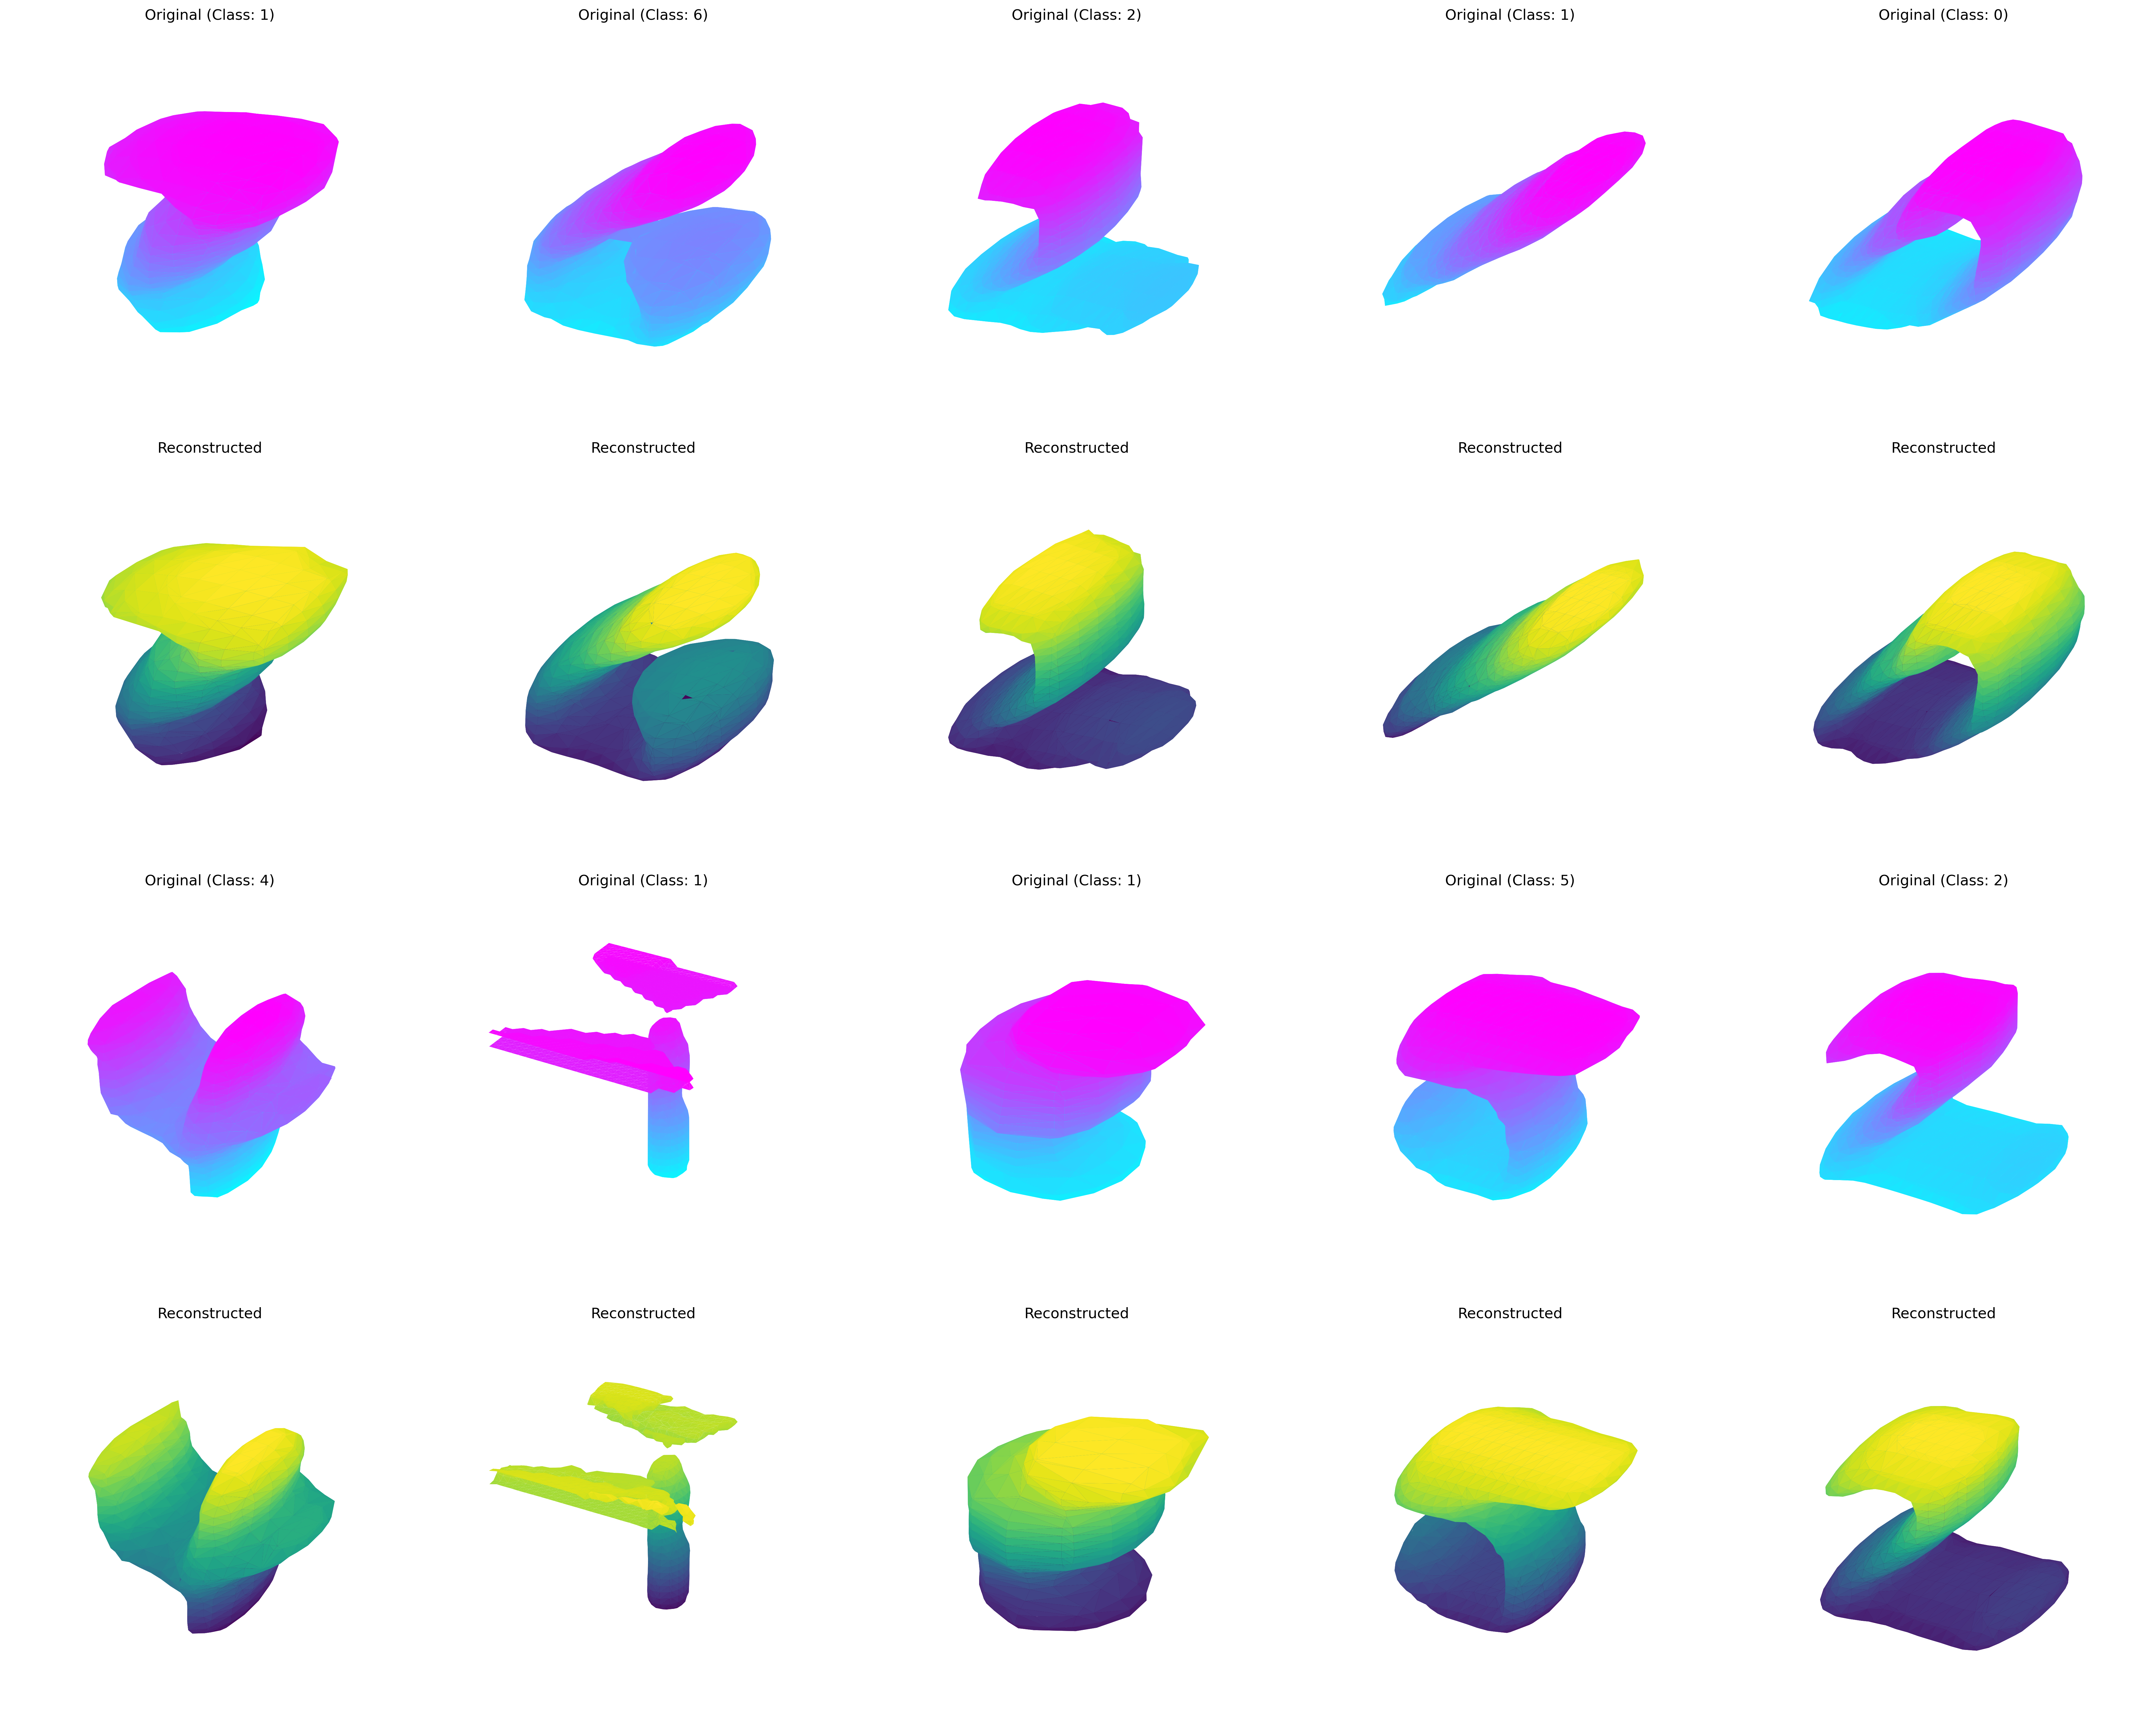

In [3]:
fig = plt.figure(figsize=(25, 20), dpi=300)

for i in range(10):
    coords, sdf, label = test_dataset[i]
    b_col = torch.zeros((coords.size(0), 1), dtype=coords.dtype)
    batched_coords = torch.cat([b_col, coords], dim=1).to(device)
    batched_sdf = sdf.to(device)
    
    x = SparseTensor(coords=batched_coords, feats=batched_sdf)
    with torch.no_grad():
        # Using forward pass directly
        pred_feats, _ = model(x)
        
    # Reconstruct original mesh
    orig_unique_vertices, orig_local_voxels, orig_merged_sdfs = c3d.conversion.grid.sparse2voxel(
        batched_coords, batched_sdf, grid_min=[-1.2, -1.2, -1.2], grid_max=[1.2, 1.2, 1.2], res=[32, 32, 32]
    )
    orig_vert, orig_tri, _, _ = c3d.ops.diff_marching_cubes(orig_unique_vertices, orig_local_voxels, orig_merged_sdfs, iso=0.0)
    
    # Reconstruct predicted mesh
    pred_unique_vertices, pred_local_voxels, pred_merged_sdfs = c3d.conversion.grid.sparse2voxel(
        batched_coords, pred_feats, grid_min=[-1.2, -1.2, -1.2], grid_max=[1.2, 1.2, 1.2], res=[32, 32, 32]
    )
    pred_vert, pred_tri, _, _ = c3d.ops.diff_marching_cubes(pred_unique_vertices, pred_local_voxels, pred_merged_sdfs, iso=0.0)
    
    # Grid math: 4 rows, 5 columns
    # Samples 0-4 go to row 1 (Original) and row 2 (Recon)
    # Samples 5-9 go to row 3 (Original) and row 4 (Recon)
    row_offset = 0 if i < 5 else 2
    col_idx = i % 5
    
    # Plot Original
    ax_orig = fig.add_subplot(4, 5, row_offset * 5 + col_idx + 1, projection='3d')
    orig_vert_np, orig_tri_np = orig_vert.detach().cpu().numpy(), orig_tri.detach().cpu().numpy()
    if len(orig_tri_np) > 0:
        ax_orig.plot_trisurf(orig_vert_np[:, 0], orig_vert_np[:, 1], orig_vert_np[:, 2], triangles=orig_tri_np, cmap='cool', edgecolor='none')
    ax_orig.set_title(f"Original (Class: {label})")
    ax_orig.axis('off')
    
    # Plot Reconstructed
    ax_pred = fig.add_subplot(4, 5, (row_offset + 1) * 5 + col_idx + 1, projection='3d')
    pred_vert_np, pred_tri_np = pred_vert.detach().cpu().numpy(), pred_tri.detach().cpu().numpy()
    if len(pred_tri_np) > 0:
        ax_pred.plot_trisurf(pred_vert_np[:, 0], pred_vert_np[:, 1], pred_vert_np[:, 2], triangles=pred_tri_np, cmap='viridis', edgecolor='none')
    ax_pred.set_title(f"Reconstructed")
    ax_pred.axis('off')

plt.tight_layout()
plt.show()


Sample 10 - Latent Coords Min: [0, 2, 0], Max: [4, 3, 5]
Sample 11 - Latent Coords Min: [0, 2, 0], Max: [5, 3, 5]
Sample 12 - Latent Coords Min: [1, 2, 0], Max: [4, 3, 5]
Sample 13 - Latent Coords Min: [0, 2, 0], Max: [3, 3, 4]
Sample 14 - Latent Coords Min: [1, 2, 0], Max: [4, 3, 4]


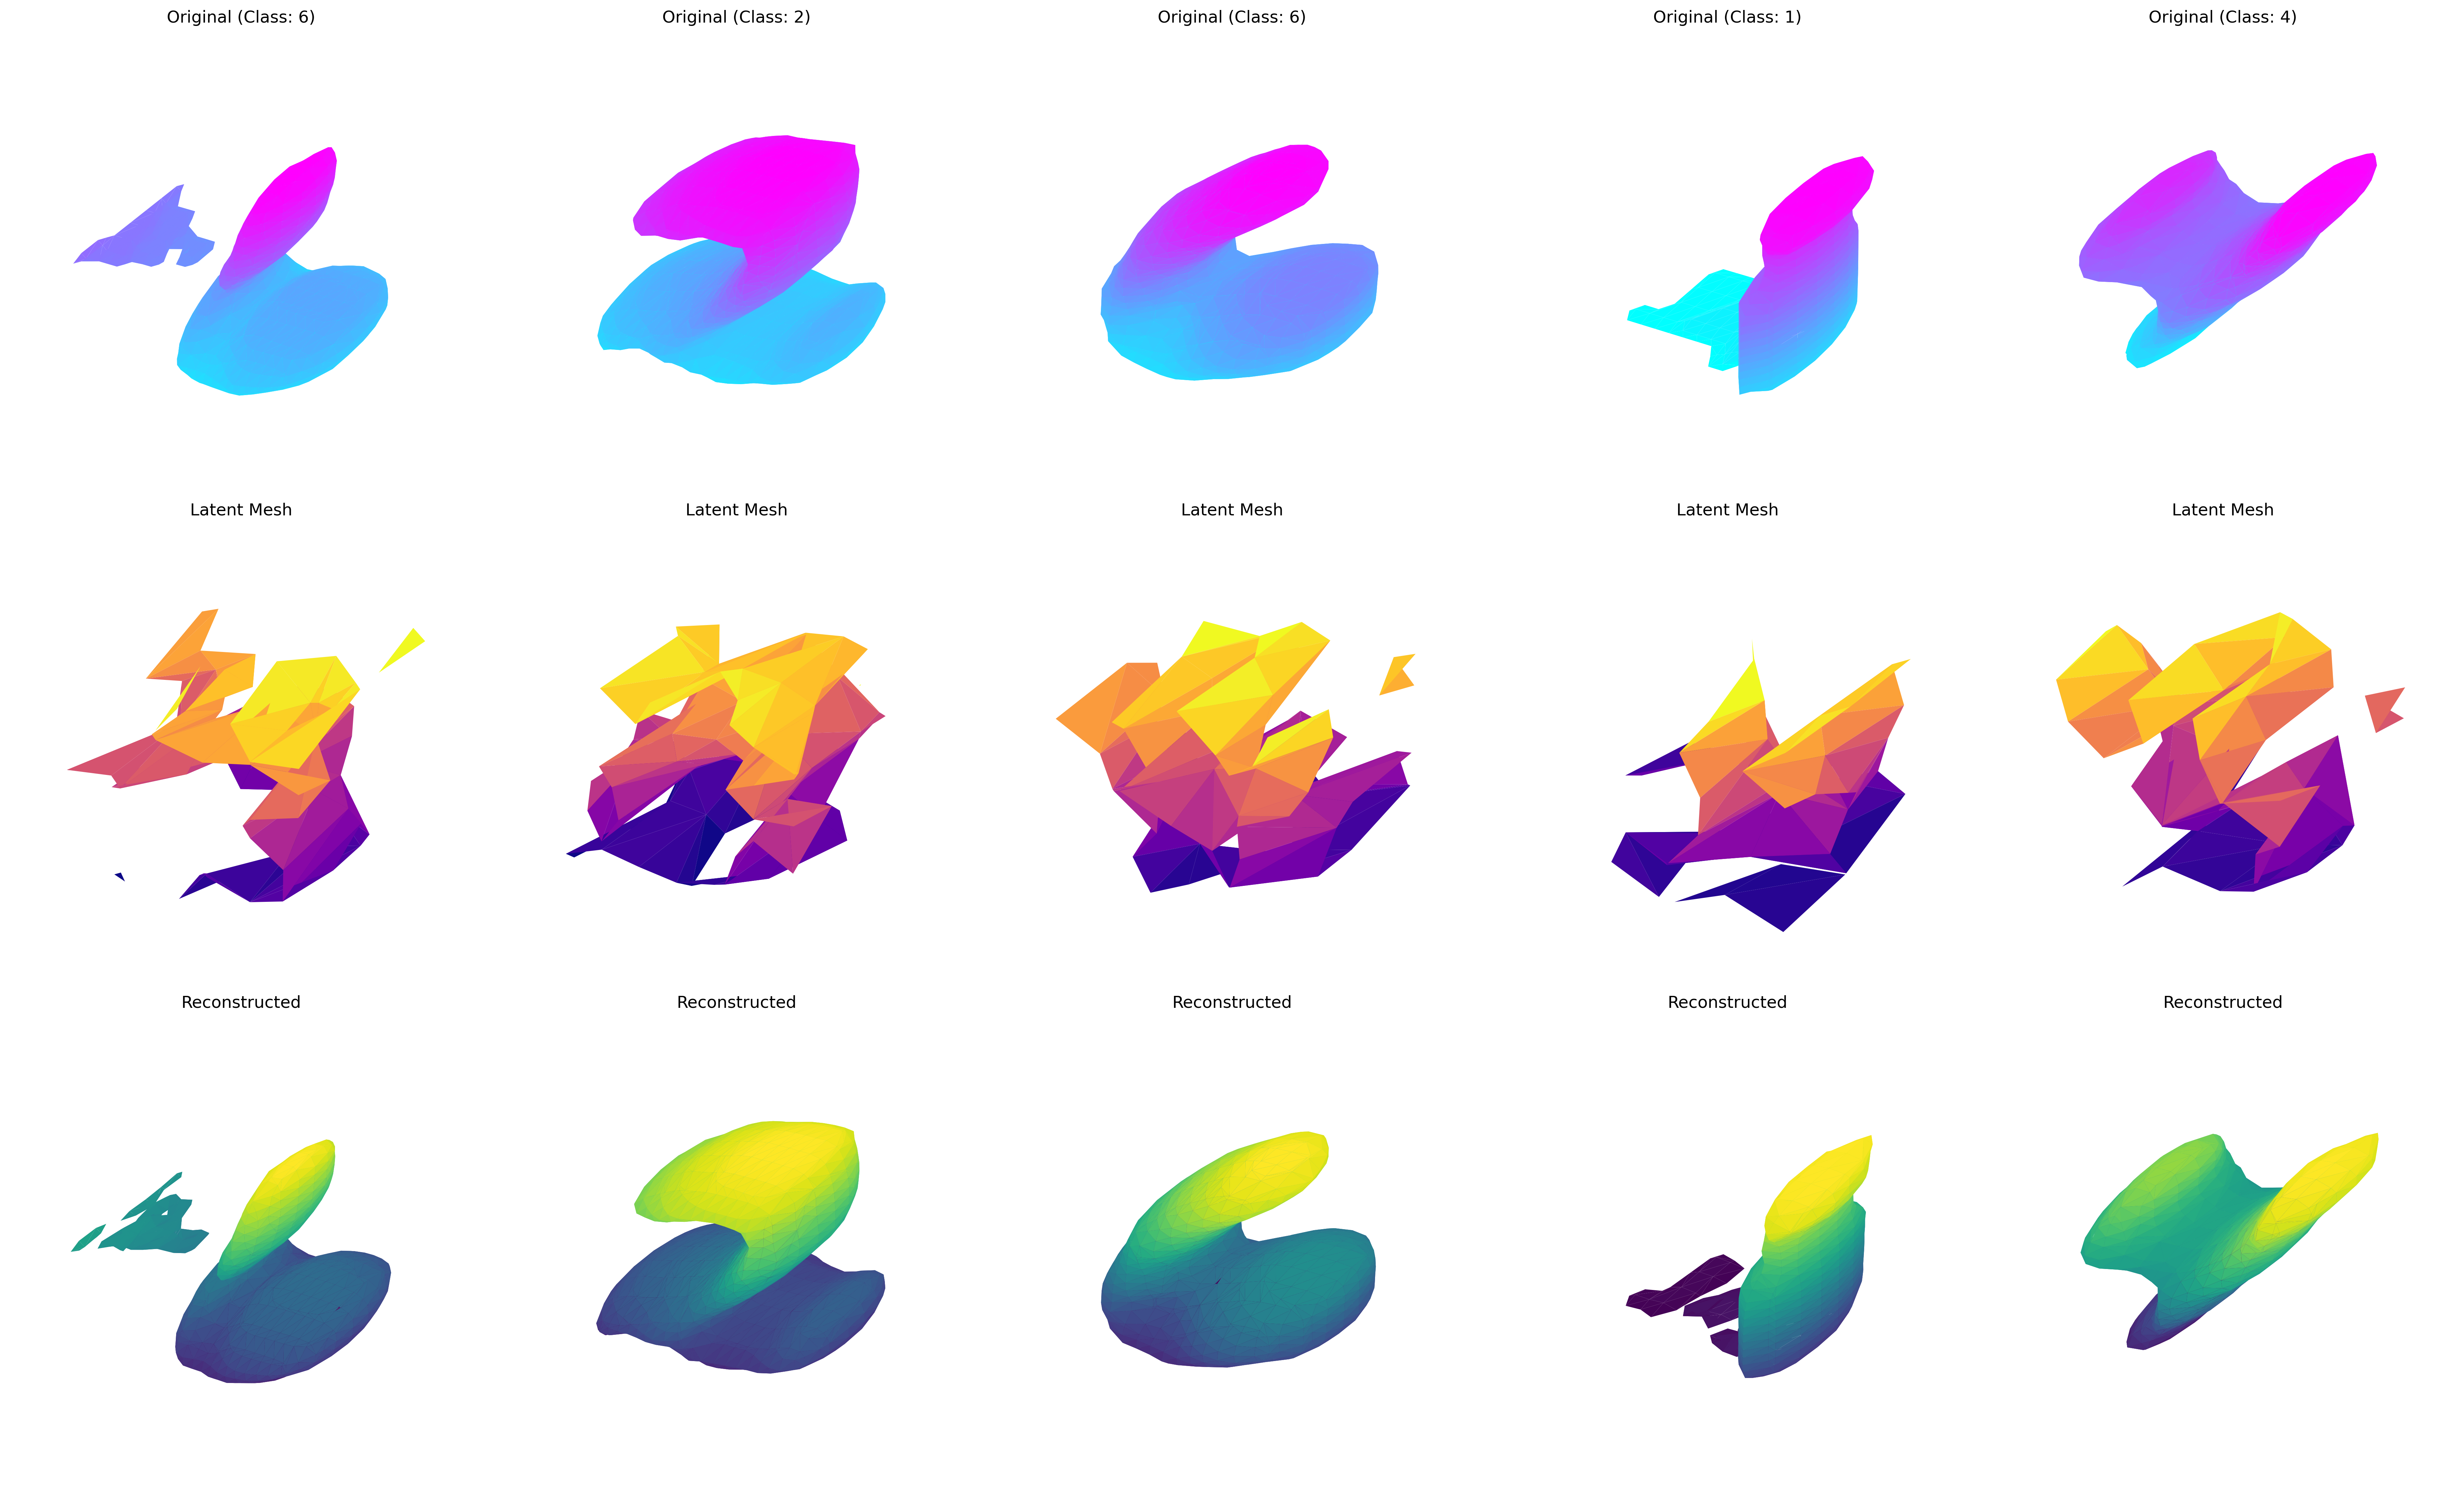

In [4]:
fig = plt.figure(figsize=(25, 15), dpi=300)

for i in range(10, 15):
    coords, sdf, label = test_dataset[i]
    b_col = torch.zeros((coords.size(0), 1), dtype=coords.dtype)
    batched_coords = torch.cat([b_col, coords], dim=1).to(device)
    batched_sdf = sdf.to(device)
    
    x = SparseTensor(coords=batched_coords, feats=batched_sdf)
    with torch.no_grad():
        z = encode_manual(model, x)
        print(f"Sample {i} - Latent Coords Min: {z.coords[:, 1:].min(dim=0)[0].tolist()}, Max: {z.coords[:, 1:].max(dim=0)[0].tolist()}")
        pred_feats = decode_manual(model, z)
        
    # Reconstruct original mesh
    orig_unique_vertices, orig_local_voxels, orig_merged_sdfs = c3d.conversion.grid.sparse2voxel(
        batched_coords, batched_sdf, grid_min=[-1.2, -1.2, -1.2], grid_max=[1.2, 1.2, 1.2], res=[32, 32, 32]
    )
    orig_vert, orig_tri, _, _ = c3d.ops.diff_marching_cubes(orig_unique_vertices, orig_local_voxels, orig_merged_sdfs, iso=0.0)
    
    # Reconstruct predicted mesh
    pred_unique_vertices, pred_local_voxels, pred_merged_sdfs = c3d.conversion.grid.sparse2voxel(
        batched_coords, pred_feats.feats, grid_min=[-1.2, -1.2, -1.2], grid_max=[1.2, 1.2, 1.2], res=[32, 32, 32]
    )
    pred_vert, pred_tri, _, _ = c3d.ops.diff_marching_cubes(pred_unique_vertices, pred_local_voxels, pred_merged_sdfs, iso=0.0)
    
    col_idx = i - 10
    
    # Plot Original
    ax_orig = fig.add_subplot(3, 5, col_idx + 1, projection='3d')
    orig_vert_np, orig_tri_np = orig_vert.detach().cpu().numpy(), orig_tri.detach().cpu().numpy()
    if len(orig_tri_np) > 0:
        ax_orig.plot_trisurf(orig_vert_np[:, 0], orig_vert_np[:, 1], orig_vert_np[:, 2], triangles=orig_tri_np, cmap='cool', edgecolor='none')
    ax_orig.set_title(f"Original (Class: {label})")
    ax_orig.axis('off')
    
    # Reconstruct latent mesh
    # z.feats has shape [N, 16], we just use the first channel to extract the mesh
    latent_unique_vertices, latent_local_voxels, latent_merged_sdfs = c3d.conversion.grid.sparse2voxel(
        z.coords, z.feats[:, :8], grid_min=[-1.2, -1.2, -1.2], grid_max=[1.2, 1.2, 1.2], res=[8, 8, 8]
    )
    latent_vert, latent_tri, _, _ = c3d.ops.diff_marching_cubes(latent_unique_vertices, latent_local_voxels, latent_merged_sdfs, iso=0.0)
    
    # Plot Latent Mesh
    ax_latent = fig.add_subplot(3, 5, 5 + col_idx + 1, projection='3d')
    latent_vert_np, latent_tri_np = latent_vert.detach().cpu().numpy(), latent_tri.detach().cpu().numpy()
    if len(latent_tri_np) > 0:
        ax_latent.plot_trisurf(latent_vert_np[:, 0], latent_vert_np[:, 1], latent_vert_np[:, 2], triangles=latent_tri_np, cmap='plasma', edgecolor='none')
    ax_latent.set_title("Latent Mesh")
    ax_latent.axis('off')
    
    # Plot Reconstructed
    ax_pred = fig.add_subplot(3, 5, 10 + col_idx + 1, projection='3d')
    pred_vert_np, pred_tri_np = pred_vert.detach().cpu().numpy(), pred_tri.detach().cpu().numpy()
    if len(pred_tri_np) > 0:
        ax_pred.plot_trisurf(pred_vert_np[:, 0], pred_vert_np[:, 1], pred_vert_np[:, 2], triangles=pred_tri_np, cmap='viridis', edgecolor='none')
    ax_pred.set_title("Reconstructed")
    ax_pred.axis('off')

plt.tight_layout()
plt.show()


In [5]:
import plotly.graph_objects as go
import plotly.subplots as sp

# We create a 2x5 subplot grid to display the latent coords for 10 digits
fig = sp.make_subplots(
    rows=2, cols=5,
    specs=[[{'type': 'scatter3d'} for _ in range(5)] for _ in range(2)],
    subplot_titles=[f"Digit {test_dataset[i][2]}" for i in range(10)],
    horizontal_spacing=0.01,
    vertical_spacing=0.05
)

for i in range(10):
    coords, sdf, label = test_dataset[i]
    b_col = torch.zeros((coords.size(0), 1), dtype=coords.dtype)
    batched_coords = torch.cat([b_col, coords], dim=1).to(device)
    batched_sdf = sdf.to(device)
    
    x = SparseTensor(coords=batched_coords, feats=batched_sdf)
    with torch.no_grad():
        z = encode_manual(model, x)
        
    z_coords = z.coords[:, 1:].detach().cpu().numpy()
    
    if len(z_coords) > 0:
        z_ax, y_ax, x_ax = z_coords[:, 0], z_coords[:, 1], z_coords[:, 2]
    else:
        z_ax, y_ax, x_ax = [], [], []

    row = (i // 5) + 1
    col = (i % 5) + 1

    scatter = go.Scatter3d(
        x=x_ax, y=y_ax, z=z_ax,
        mode='markers',
        marker=dict(
            size=6,
            color=z_ax, # Color by depth
            colorscale='Viridis',
            opacity=0.8
        ),
        name=f"Digit {label}",
        showlegend=False
    )
    fig.add_trace(scatter, row=row, col=col)

# Update layout to make it look clean
fig.update_layout(
    title="Sparse Latent Coordinates Visualization (Plotly)",
    height=800,
    width=1600,
    scene=dict(aspectmode='data'),
    margin=dict(l=0, r=0, b=0, t=50)
)

# Show axes to visualize scale and orientation
for i in range(1, 11):
    fig.layout[f'scene{i if i > 1 else ""}'].update(
        xaxis=dict(visible=True, title='X'),
        yaxis=dict(visible=True, title='Y'),
        zaxis=dict(visible=True, title='Z')
    )

fig.show()


In [ ]:
import plotly.graph_objects as go
import plotly.subplots as sp

# We create a 2x5 subplot grid to display the latent coords for 10 digits
fig = sp.make_subplots(
    rows=2, cols=5,
    specs=[[{'type': 'scatter3d'} for _ in range(5)] for _ in range(2)],
    subplot_titles=[f"Digit {test_dataset[i][2]}" for i in range(10)],
    horizontal_spacing=0.01,
    vertical_spacing=0.05
)

for i in range(10):
    coords, sdf, label = test_dataset[i]
    b_col = torch.zeros((coords.size(0), 1), dtype=coords.dtype)
    batched_coords = torch.cat([b_col, coords], dim=1).to(device)
    batched_sdf = sdf.to(device)
    
    x = SparseTensor(coords=batched_coords, feats=batched_sdf)
    with torch.no_grad():
        z = encode_manual(model, x)
        
    z_coords = z.coords[:, 1:].detach().cpu().numpy()
    
    if len(z_coords) > 0:
        z_ax, y_ax, x_ax = z_coords[:, 0], z_coords[:, 1], z_coords[:, 2]
    else:
        z_ax, y_ax, x_ax = [], [], []

    row = (i // 5) + 1
    col = (i % 5) + 1

    scatter = go.Scatter3d(
        x=x_ax, y=y_ax, z=z_ax,
        mode='markers',
        marker=dict(
            size=6,
            color=z_ax, # Color by depth
            colorscale='Viridis',
            opacity=0.8
        ),
        name=f"Digit {label}",
        showlegend=False
    )
    fig.add_trace(scatter, row=row, col=col)

# Update layout to make it look clean
fig.update_layout(
    title="Sparse Latent Coordinates Visualization (Plotly)",
    height=800,
    width=1600,
    scene=dict(aspectmode='data'),
    margin=dict(l=0, r=0, b=0, t=50)
)

# Show axes to visualize scale and orientation
for i in range(1, 11):
    fig.layout[f'scene{i if i > 1 else ""}'].update(
        xaxis=dict(visible=True, title='X'),
        yaxis=dict(visible=True, title='Y'),
        zaxis=dict(visible=True, title='Z')
    )

fig.show()
